In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from SamplingMethods import Sampler_class
import plotly.express as px
from ax.api.client import Client

# ModelGP_M25

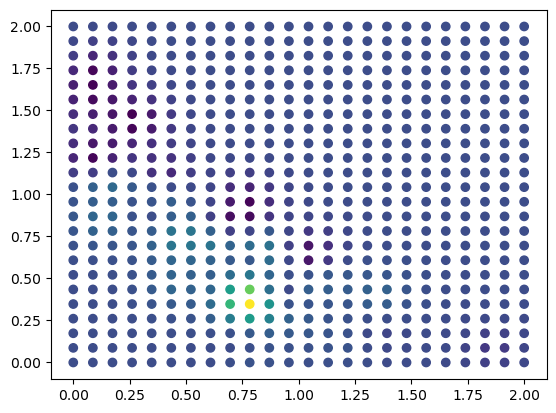

In [2]:
client = Client()
client = client.load_from_json_file("/Users/thomasdodd/Library/CloudStorage/OneDrive-MillfieldEnterprisesLimited/Cambridge/PhD/writing/papers/UoC_Paper1/sandbox/Emulation/StoichModelGP/ModelGP_M25.json")
client.get_next_trials(max_trials=1)
client.predict([{"n_ci":0.1,"n_it":0.1}])[0]["t1"][0]

n = 25
iCoords_arr = np.linspace(0,2,n-1)
jCoords_arr = np.linspace(0,2,n-1)

ijCoords_lis = []
ijCoords_lis_nonDict = []
for i in iCoords_arr:
    for j in jCoords_arr:
        ijCoords_lis.append({"n_ci":i,"n_it":j})
        ijCoords_lis_nonDict.append([i,j])
y_pred = client.predict(ijCoords_lis)
y_pred_lis = []
for i in y_pred:
    y_pred_lis.append(i["t1"][0])

n_ci_bits = np.array(ijCoords_lis_nonDict).T[0]
n_it_bits = np.array(ijCoords_lis_nonDict).T[1]
plt.scatter(x=n_ci_bits,y=n_it_bits,c=y_pred_lis,cmap='viridis')

In [3]:
pseudorandom_100_dodd_27 = pd.read_pickle(filepath_or_buffer="/Users/thomasdodd/Library/CloudStorage/OneDrive-MillfieldEnterprisesLimited/Cambridge/PhD/writing/papers/UoC_Paper1/sandbox/Emulation/TestStoichModelGP_M25/DataGenerated/pseudorandom_27.pkl")[0].tolist()
quasirandom_100_dodd_27 = pd.read_pickle(filepath_or_buffer="/Users/thomasdodd/Library/CloudStorage/OneDrive-MillfieldEnterprisesLimited/Cambridge/PhD/writing/papers/UoC_Paper1/sandbox/Emulation/TestStoichModelGP_M25/DataGenerated/quasirandom_27.pkl")[0].tolist()
sequential_100_mipt_9_27_3 = pd.read_pickle(filepath_or_buffer="/Users/thomasdodd/Library/CloudStorage/OneDrive-MillfieldEnterprisesLimited/Cambridge/PhD/writing/papers/UoC_Paper1/sandbox/Emulation/TestStoichModelGP_M25/DataGenerated/normal_MIPT_9_27_3.pkl")[0].tolist()
Bayes_100_PI_9_27_3 =  pd.read_pickle(filepath_or_buffer="/Users/thomasdodd/Library/CloudStorage/OneDrive-MillfieldEnterprisesLimited/Cambridge/PhD/writing/papers/UoC_Paper1/sandbox/Emulation/TestStoichModelGP_M25/DataGenerated/normal_PI_9_27_3.pkl")[0].tolist()
Bayes_100_EI_9_27_3 = pd.read_pickle(filepath_or_buffer="/Users/thomasdodd/Library/CloudStorage/OneDrive-MillfieldEnterprisesLimited/Cambridge/PhD/writing/papers/UoC_Paper1/sandbox/Emulation/TestStoichModelGP_M25/DataGenerated/normal_EI_9_27_3.pkl")[0].tolist()

Simulations = [pseudorandom_100_dodd_27,quasirandom_100_dodd_27,sequential_100_mipt_9_27_3,Bayes_100_PI_9_27_3,Bayes_100_EI_9_27_3]

all = pseudorandom_100_dodd_27+quasirandom_100_dodd_27+sequential_100_mipt_9_27_3+Bayes_100_PI_9_27_3+Bayes_100_EI_9_27_3

print(len(pseudorandom_100_dodd_27))
print(len(quasirandom_100_dodd_27))
print(len(sequential_100_mipt_9_27_3))
print(len(Bayes_100_PI_9_27_3))
print(len(Bayes_100_EI_9_27_3))

700
700
1000
1000
1000


In [4]:
pseudorandom_100_dodd_27_name = []
quasirandom_100_dodd_27_name = []
sequential_100_mipt_9_27_3_name = []
Bayes_100_PI_9_27_3_name = []
Bayes_100_EI_9_27_3_name = []
for i in range(len(pseudorandom_100_dodd_27)):
    pseudorandom_100_dodd_27_name.append("PR\n27")
    quasirandom_100_dodd_27_name.append("QR\n27")
    sequential_100_mipt_9_27_3_name.append("MIPT\n9,27,3")
    Bayes_100_PI_9_27_3_name.append("PI\n9,27,3")
    Bayes_100_EI_9_27_3_name.append("EI\n9,27,3")

all_names = pseudorandom_100_dodd_27_name+quasirandom_100_dodd_27_name+sequential_100_mipt_9_27_3_name+Bayes_100_PI_9_27_3_name+Bayes_100_EI_9_27_3_name

In [5]:
hex = {
    "0":"#E76F51",
    "1":"#F4A261",
    "2":"#E9C46A",
    "3":"#8AB17D",
    "4":"#287271",
    }

In [6]:
pseudorandom_100_dodd_27_hue = []
quasirandom_100_dodd_27_hue = []
sequential_100_mipt_9_27_3_hue = []
Bayes_100_PI_9_27_3_hue = []
Bayes_100_EI_9_27_3_hue = []
for i in range(len(pseudorandom_100_dodd_27)):
    pseudorandom_100_dodd_27_hue.append("0")
    quasirandom_100_dodd_27_hue.append("1")
    sequential_100_mipt_9_27_3_hue.append("2")
    Bayes_100_PI_9_27_3_hue.append("3")
    Bayes_100_EI_9_27_3_hue.append("4")

all_hues = pseudorandom_100_dodd_27_hue+quasirandom_100_dodd_27_hue+sequential_100_mipt_9_27_3_hue+Bayes_100_PI_9_27_3_hue+Bayes_100_EI_9_27_3_hue

In [7]:
ndf = pd.DataFrame({"y":all,"type":all_names,"hue":all_hues})
ndf

ValueError: All arrays must be of the same length

In [ ]:
# plt.gcf().set_size_inches(10, 4)
# sns.set_theme(style="whitegrid")
# ax = sns.swarmplot(x="type", y="y",hue="hue", palette=hex, data=ndf, size=0.75, legend=False)
# df_means = ndf.groupby("type")["y"].agg("mean").reset_index()
# xlim = ax.get_xlim()
# ylim = ax.get_ylim()
# sns.scatterplot(x="type", y="y", marker='X', color='black', s=100, zorder=3, ax=ax, legend=False, data=df_means)
# ax.set_xlim(xlim)
# ax.set_ylim(ylim)
# plt.title(f"Optimising ModelMk4: {len(pseudorandom_100_dodd_27)} Trials & Random 8 Sample Prior")
# plt.xlabel("Optimisation Type")
# plt.ylabel("Best Mass Loss (%)")
# plt.ylim(bottom=12,top=19)
# plt.show()

In [ ]:
# Global Maximum
# 18.766577458826873
# [np.float64(0.3469387755102041), np.float64(0.6530612244897959), np.float64(0.7653061224489796)]

In [ ]:
# Threshold = 18.5
# SimulationNumberOfPointsExceedingThreshold = []
# PercentageOfPointsExceedingThreshold = []
# for simulation in Simulations:
#     counter = 0
#     for i in simulation:
#         if i > Threshold:
#             counter+=1
#     SimulationNumberOfPointsExceedingThreshold.append(counter)
#     PercentageOfPointsExceedingThreshold.append(round((counter/len(simulation))*100,2))
# print(SimulationNumberOfPointsExceedingThreshold)
# print(PercentageOfPointsExceedingThreshold)

# Visualisation For Paper

In [ ]:
nndf = ndf.drop(ndf[ndf['type'] == "PI\n9,27,1"].index)
nndf = nndf.drop(nndf[nndf['type'] == "EI\n9,27,1"].index)
nndf = nndf.drop(nndf[nndf['type'] == "EI\n9,27,2"].index)

nndf = nndf.replace("PR\n27","One-Shot\nPseudorandom")
nndf = nndf.replace("QR\n27","One-Shot\nQuasirandom")
nndf = nndf.replace("MIPT\n9,27,3","Sequential\nSpace-Filling")
nndf = nndf.replace("PI\n9,27,3","Sequential\nBayesian (PI)")
nndf = nndf.replace("EI\n9,27,3","Sequential\nBayesian (EI)")
nndf

In [ ]:
# plt.gcf().set_size_inches(5, 4)
# sns.set_style("ticks")
# ax = sns.swarmplot(x="type", y="y",hue="hue", palette=hex, data=nndf, size=0.8, legend=False)
# df_means = nndf.groupby("type")["y"].agg("mean").reset_index()
# df_means["hue"]=["0","1","6","3"]
# xlim = ax.get_xlim()
# ylim = ax.get_ylim()
# sns.scatterplot(x="type", y="y", hue="hue", marker='X', palette=hex, color='black', s=100, zorder=3, ax=ax, legend=False, data=df_means, edgecolors="black")
# plt.scatter(x="One-Shot\nPseudorandom",y=20,marker="X",color="black",edgecolors="black",s=100,label="Mean")
# plt.scatter(x="One-Shot\nPseudorandom",y=20,marker=".",color="black",edgecolors="black",s=0.8,label="Simulation")
# ax.set_xlim(xlim)
# ax.set_ylim(ylim)
# # plt.title(f"Optimising ModelMk4: {len(pseudorandom_100_dodd_27)} Trials & Random 8 Sample Prior")
# plt.xlabel("Sampling Method",fontsize=12)
# plt.ylabel(r'Best Percentage Mass Loss, $\Delta$m$^\circ_\%$ (%)',fontsize=12)
# plt.ylim(bottom=12,top=19)
# plt.xticks(fontsize=10)
# plt.legend(loc='upper left',ncols=2,fontsize="10")
# plt.show()

In [ ]:
plt.gcf().set_size_inches(14, 4)
sns.set_style("ticks")
# ax = sns.swarmplot(x="type", y="y",hue="hue", palette=hex, data=nndf, size=1.5, legend=False)
ax = sns.swarmplot(x="type", y="y",hue="hue", palette=hex, data=nndf, size=1.5, legend=False)
df_means = nndf.groupby("type")["y"].agg("mean").reset_index()
df_std = nndf.groupby("type")["y"].agg("std").reset_index()
# print(df_means)
df_means["hue"]=["0","1","4","3","2"]
xlim = ax.get_xlim()
ylim = ax.get_ylim()
sns.scatterplot(x="type", y="y", hue="hue", marker='X', palette=hex, color='black', s=100, zorder=3, ax=ax, legend=False, data=df_means, edgecolors="black")
plt.scatter(x="One-Shot\nPseudorandom",y=20,marker="X",color="black",edgecolors="black",s=100,label="Mean")
plt.scatter(x="One-Shot\nPseudorandom",y=20,marker=".",color="black",edgecolors="black",s=0.8,label="Simulation")
ax.set_xlim(xlim)
ax.set_ylim(ylim)
# plt.title(f"Optimising ModelMk4: {len(pseudorandom_100_dodd_27)} Trials & Random 8 Sample Prior")

# plt.hlines(18.5,xmin=-1,xmax=-0.41,linestyle="dashed",alpha=0.3)
# plt.hlines(18.5,xmin=0.9,xmax=4,linestyle="dashed",alpha=0.3)
# plt.text(x=-0.4,y=18.36,s="\"Region of Global Optimality\" Threshold",alpha=0.8,fontsize="14")

plt.xlabel("Sampling Method",fontsize=16)
plt.ylabel(r'Best Percentage Mass Loss, $\Delta$m$^\circ_\%$ (%)',fontsize=13)
plt.ylim(bottom=12,top=19)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.legend(bbox_to_anchor=(0.5, 0.72),ncols=1,fontsize="16")
plt.tight_layout()
plt.text(x=-0.45,y=18.5,s="Model:GP_Matern_nu2.5",fontsize=15)
plt.savefig(fname='SimulationResultOverview.pdf',dpi=1000,format='pdf')

In [ ]:
df_means

In [ ]:
df_std